In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [5]:
data = pd.read_csv('GOOGL.csv')

In [7]:
print("Dataset Shape  :", data.shape)
print("Column Names   :", data.columns.tolist())
print("First 5 rows   :")
print(data.head())


Dataset Shape  : (4431, 7)
Column Names   : ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
First 5 rows   :
         Date       Open       High        Low      Close  Adj Close    Volume
0  2004-08-19  50.050049  52.082081  48.028027  50.220219  50.220219  44659096
1  2004-08-20  50.555557  54.594597  50.300301  54.209209  54.209209  22834343
2  2004-08-23  55.430431  56.796799  54.579578  54.754753  54.754753  18256126
3  2004-08-24  55.675674  55.855858  51.836838  52.487488  52.487488  15247337
4  2004-08-25  52.532532  54.054054  51.991993  53.053055  53.053055   9188602


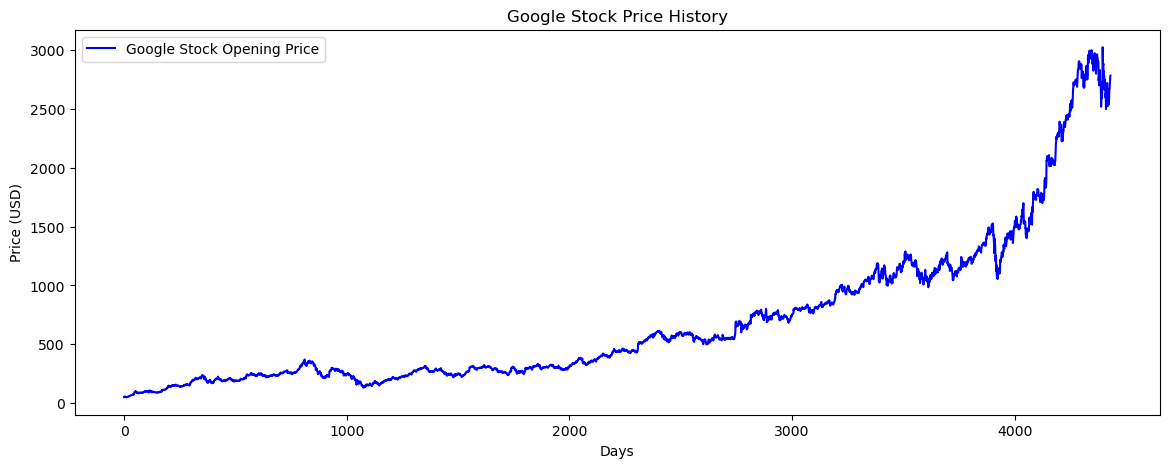

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(data['Open'], color='blue', label='Google Stock Opening Price')
plt.title('Google Stock Price History')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

In [11]:
# Extract only the 'Open' price column and convert to 2D array
dataset = data['Open'].values.reshape(-1, 1)

print("Dataset shape after reshape:", dataset.shape)


Dataset shape after reshape: (4431, 1)


In [13]:
scaler  = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)

print("Min value after scaling:", dataset.min())
print("Max value after scaling:", dataset.max())

Min value after scaling: 0.0
Max value after scaling: 1.0


In [15]:
training_data_len = int(len(dataset) * 0.8)

training_data = dataset[:training_data_len]
testing_data  = dataset[training_data_len:]

print("Total data points    :", len(dataset))
print("Training data points :", len(training_data))
print("Testing data points  :", len(testing_data))

Total data points    : 4431
Training data points : 3544
Testing data points  : 887


In [17]:
def create_dataset(dataset, time_step=1):
    X, Y = [], []
    for i in range(len(dataset) - time_step - 1):
        X.append(dataset[i:(i + time_step), 0])
        Y.append(dataset[i + time_step, 0])
    return np.array(X), np.array(Y)

# Use 60 days as time step
time_step = 60

X_train, Y_train = create_dataset(training_data, time_step)
X_test,  Y_test  = create_dataset(testing_data,  time_step)

print("X_train shape (before reshape):", X_train.shape)
print("X_test shape  (before reshape):", X_test.shape)

X_train shape (before reshape): (3483, 60)
X_test shape  (before reshape): (826, 60)


In [19]:
# LSTM needs 3D input: (samples, time_steps, features)
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test  = np.reshape(X_test,  (X_test.shape[0],  X_test.shape[1],  1))

print("X_train shape (after reshape) :", X_train.shape)
print("X_test shape  (after reshape) :", X_test.shape)

X_train shape (after reshape) : (3483, 60, 1)
X_test shape  (after reshape) : (826, 60, 1)


In [21]:
model = Sequential()

# First LSTM layer - return_sequences=True because another LSTM follows
model.add(LSTM(units=50, return_sequences=True,
               input_shape=(X_train.shape[1], 1)))
model.add(Dropout(0.2))

# Second LSTM layer - return_sequences=True because another LSTM follows
model.add(LSTM(units=50, return_sequences=True))
model.add(Dropout(0.2))

# Third LSTM layer - return_sequences=False (Dense layer follows)
model.add(LSTM(units=50, return_sequences=False))
model.add(Dropout(0.2))

# Output Dense layer - predicts 1 value (next day's price)
model.add(Dense(units=1))

model.summary()


C:\Users\Lenovo\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 60, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 60, 50)              │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 60, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_2 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 50)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

In [25]:
history = model.fit(
    X_train, Y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 27s 150ms/step - loss: 0.0024 - val_loss: 1.7637e-04
Epoch 2/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 135ms/step - loss: 1.4889e-04 - val_loss: 4.9748e-04
Epoch 3/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 1.5533e-04 - val_loss: 4.1006e-04
Epoch 4/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 136ms/step - loss: 1.4821e-04 - val_loss: 3.2499e-04
Epoch 5/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - loss: 1.1275e-04 - val_loss: 7.9573e-04
Epoch 6/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - loss: 1.0985e-04 - val_loss: 2.1866e-04
Epoch 7/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 134ms/step - loss: 1.0289e-04 - val_loss: 2.5469e-04
Epoch 8/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s 133ms/step - loss: 1.0590e-04 - val_loss: 1.6301e-04
Epoch 9/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 132ms/step - loss: 9.6314e-05 - val_loss: 2.1845e-04
Epoch 10/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 20s 131ms/step - loss: 1.1043e-04 - val_loss: 4.9164e-04
Epoch 11/100
98/98 ━━━━━━━━━━━━━━━━━━━━ 13s

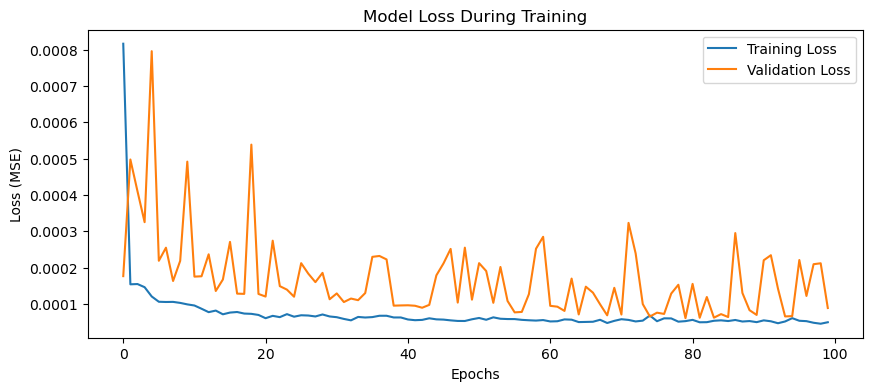

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss During Training')
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [29]:
predictions = model.predict(X_test)

26/26 ━━━━━━━━━━━━━━━━━━━━ 8s 217ms/step


In [31]:
# We scaled data earlier, now reverse it to get actual prices
predictions = scaler.inverse_transform(predictions)
Y_test_actual = scaler.inverse_transform(Y_test.reshape(-1, 1))

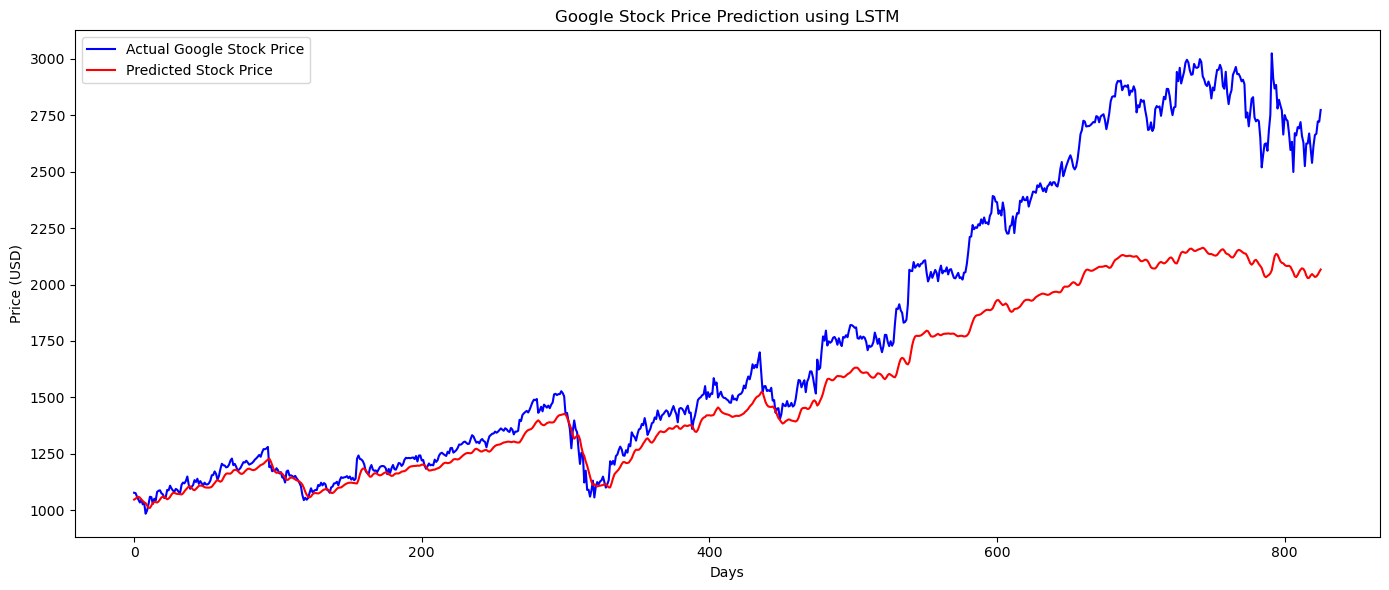

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(Y_test_actual,  color='blue',  label='Actual Google Stock Price')
plt.plot(predictions,    color='red',   label='Predicted Stock Price')
plt.title('Google Stock Price Prediction using LSTM')
plt.xlabel('Days')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

mse  = mean_squared_error(Y_test_actual, predictions)
rmse = math.sqrt(mse)
mae  = mean_absolute_error(Y_test_actual, predictions)

print(f"Mean Squared Error  (MSE)  : {mse:.4f}")
print(f"Root Mean Sq Error  (RMSE) : {rmse:.4f}")
print(f"Mean Absolute Error (MAE)  : {mae:.4f}")

Mean Squared Error  (MSE)  : 128582.6285
Root Mean Sq Error  (RMSE) : 358.5842
Mean Absolute Error (MAE)  : 241.8559
